In [1]:
python3 - <<'PY'
from osgeo import gdal
import numpy as np

sr = "/home/jovyan/scratch/eds/tiles/p089r084/sr/2024/202408/ls89sr_p089r084_20240831_nbart6m6_clr.tif"
ds = gdal.Open(sr)
b1 = ds.GetRasterBand(1).ReadAsArray()
nodata = ds.GetRasterBand(1).GetNoDataValue()
nodata = 0 if nodata is None else nodata

total = b1.size
zeros = int((b1 == nodata).sum())
print("nodata value:", nodata)
print("zeros:", zeros, "total:", total, "pct:", zeros/total*100)
PY


SyntaxError: invalid syntax (3701030381.py, line 1)

In [2]:
from osgeo import gdal
import numpy as np

# Path to a *_clr SR file
sr_path = "/home/jovyan/scratch/eds/tiles/p089r084/sr/2024/202408/ls89sr_p089r084_20240831_nbart6m6_clr.tif"


In [3]:
ds = gdal.Open(sr_path)
if ds is None:
    raise RuntimeError(f"Failed to open {sr_path}")

band = ds.GetRasterBand(1)
arr = band.ReadAsArray()


/env/lib/python3.12/site-packages/osgeo/gdal.py:330: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


In [4]:
nodata = band.GetNoDataValue()

# Many EDS products implicitly use 0 as nodata even if not declared
if nodata is None:
    nodata = 0

print("NoData value:", nodata)


NoData value: -999.0


In [6]:
total_pixels = arr.size
nodata_pixels = int((arr == nodata).sum())
valid_pixels = total_pixels - nodata_pixels

print(f"Total pixels : {total_pixels:,}")
print(f"NoData pixels: {nodata_pixels:,}")
print(f"Valid pixels : {valid_pixels:,}")
print(f"NoData %     : {nodata_pixels / total_pixels * 100:.2f}%")


Total pixels : 55,952,100
NoData pixels: 43,631,571
Valid pixels : 12,320,529
NoData %     : 77.98%


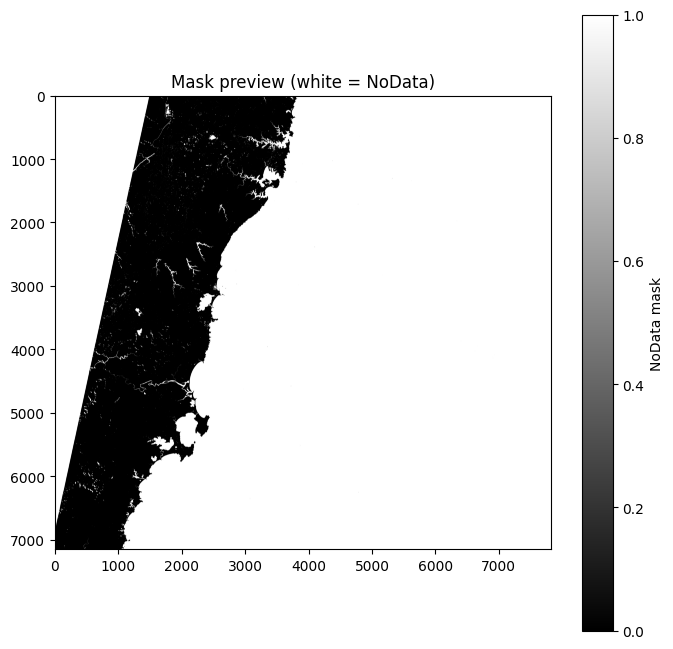

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(arr == nodata, cmap="gray")
plt.title("Mask preview (white = NoData)")
plt.colorbar(label="NoData mask")
plt.show()


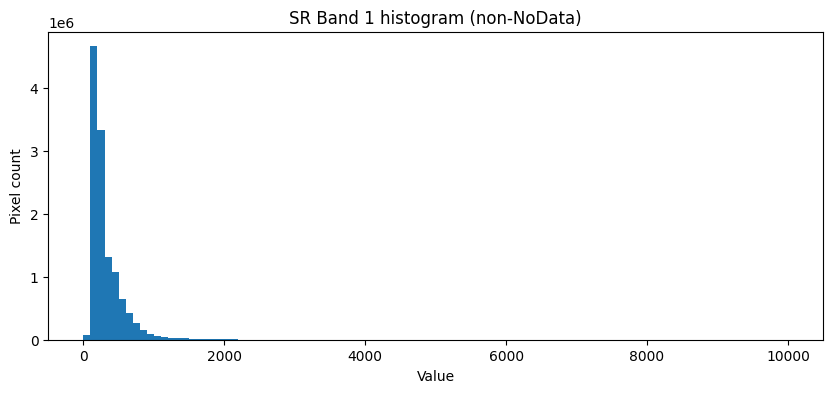

In [8]:
valid = arr[arr != nodata]

plt.figure(figsize=(10, 4))
plt.hist(valid.ravel(), bins=100)
plt.title("SR Band 1 histogram (non-NoData)")
plt.xlabel("Value")
plt.ylabel("Pixel count")
plt.show()
